# Phase II: Exploratory Data Analysis (EDA) — Comparative Analysis

This notebook focuses on the direct comparison between the terminology used in Resumes and Job Descriptions, identifying the "Language Gap".

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

%matplotlib inline
sns.set_style("whitegrid")

## 1. Load Data Subsets

In [2]:
df_resumes = pd.read_csv("../data/raw/resumes/Resume/Resume.csv")
df_jobs = pd.read_csv("../data/raw/jobs/job_descriptions.csv", nrows=20000)

print(f"Resumes: {df_resumes.shape}, Jobs (Sample): {df_jobs.shape}")

Resumes: (2484, 4), Jobs (Sample): (20000, 23)


## 2. Global Terminology Overlap
Comparing the most frequent words (unigrams) between both datasets to see if they "speak the same language".

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_vocab(corpus, top_n=50):
    vec = CountVectorizer(stop_words='english', max_features=top_n).fit(corpus)
    return set(vec.vocabulary_.keys())

resume_vocab = get_top_vocab(df_resumes['Resume_str'].astype(str))
job_vocab = get_top_vocab(df_jobs['Job Description'].astype(str))

overlap = resume_vocab.intersection(job_vocab)
missing_in_resume = job_vocab - resume_vocab
missing_in_jobs = resume_vocab - job_vocab

print(f"Top 50 terms overlap size: {len(overlap)}")
print(f"Terms in Jobs but NOT in Top 50 Resumes: {missing_in_resume}")
print(f"Terms in Resumes but NOT in Top 50 Jobs: {missing_in_jobs}")

Top 50 terms overlap size: 15
Terms in Jobs but NOT in Top 50 Resumes: {'legal', 'implement', 'social', 'performance', 'needs', 'user', 'strategies', 'compliance', 'provide', 'products', 'focus', 'issues', 'content', 'security', 'managing', 'conduct', 'ensure', 'media', 'maintain', 'applications', 'create', 'ensuring', 'research', 'improve', 'organizations', 'designers', 'optimize', 'manage', 'brand', 'develop', 'software', 'analyze', 'teams', 'oversee', 'managers'}
Terms in Resumes but NOT in Top 50 Jobs: {'01', 'accounting', 'process', 'project', 'operations', 'microsoft', 'service', 'current', '2014', 'development', 'team', 'customers', 'training', 'management', 'university', 'managed', 'office', 'high', 'staff', 'reports', 'analysis', 'client', 'state', 'skills', 'education', 'new', 'experience', 'developed', 'accounts', 'professional', 'company', 'manager', 'program', 'city', 'information'}


## 3. Skill Coverage Analysis
Pick a category (e.g., 'Data Science') and see how its skills match 'Data Scientist' job descriptions.

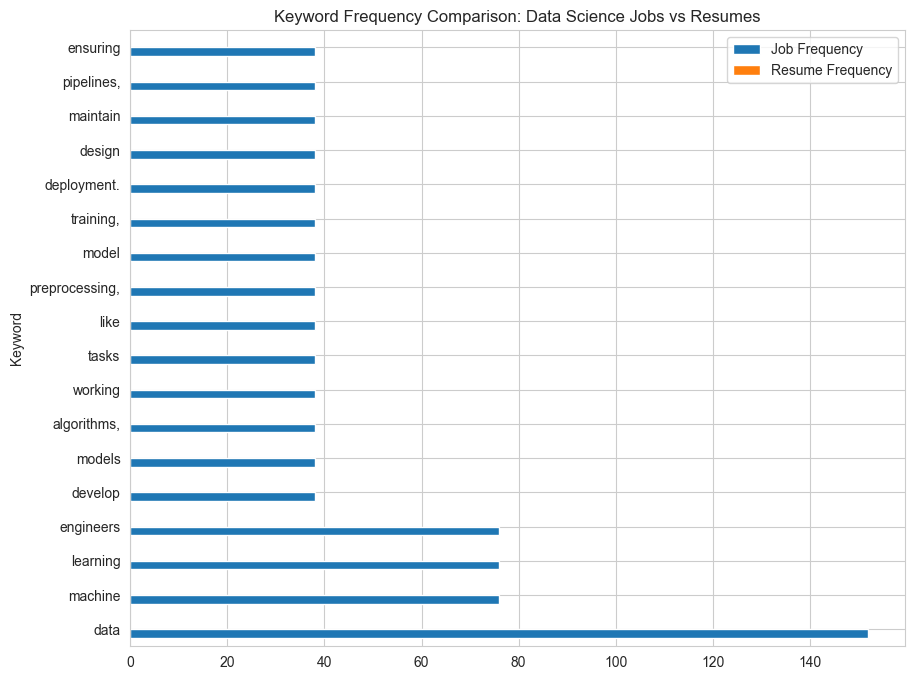

In [4]:
def extract_skills_freq(text_series):
    # Simple whitespace split for demo; in Phase 3 we'll use a better preprocessor
    tokens = " ".join(text_series.astype(str)).lower().split()
    return Counter(tokens)

# Sample comparison for 'Data Science'
ds_resumes = df_resumes[df_resumes['Category'] == 'DATA SCIENCE']['Resume_str']
ds_jobs = df_jobs[df_jobs['Job Title'].str.contains('Data Scientist', case=False, na=False)]['Job Description']

res_freq = extract_skills_freq(ds_resumes)
job_freq = extract_skills_freq(ds_jobs)

# Pick top 10 keywords from jobs and see their presence in resumes
top_job_keywords = [k for k, v in job_freq.most_common(20) if len(k) > 3]
comp_data = []
for k in top_job_keywords:
    comp_data.append({'Keyword': k, 'Job Frequency': job_freq[k], 'Resume Frequency': res_freq[k]})

comp_df = pd.DataFrame(comp_data)
comp_df.set_index('Keyword').plot(kind='barh', figsize=(10, 8))
plt.title("Keyword Frequency Comparison: Data Science Jobs vs Resumes")
plt.show()

## 4. Insight Summary
- Are resumes using the same technical verbs as jobs?
- Is there a significant vocabulary gap in specific sectors?
- This informs our **Feature Engineering** (Phase 4) on whether to use TF-IDF weightings or Dense Embeddings to bridge the gap.